In [1]:
from safetensors.torch import load_file

# Download and load directly
from huggingface_hub import hf_hub_download

# loras = []
# for filename in [
#     "rerun-seed123/adapter_model.safetensors", 
#     "rerun-seed456/adapter_model.safetensors", 
#     "rerun-seed789/adapter_model.safetensors", 
# ]:
#     path = hf_hub_download(
#         "persona-shattering-lasr/20Feb-n-plus",
#         filename=filename
#     )
#     loras.append(load_file(path))
# loras

/Users/anton/dev/LASR/persona-shattering-lasr/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# path = hf_hub_download(
#     "persona-shattering-lasr/20Feb-n-plus",
#     filename="checkpoints/final/adapter_model.safetensors"
# )
# loras.append(load_file(path))

In [3]:

# adapter_flattened_weights = {}
# for persona in tqdm(adapters):
#     if persona in adapter_flattened_weights:
#         continue
#     # Download just the adapter files
#     path = snapshot_download(REPO, allow_patterns=[f"{persona}/*"])

#     # Load config
#     config = PeftConfig.from_pretrained(path, subfolder=persona)
#     print(config.r, config.lora_alpha, config.target_modules)

#     # Load weights
#     weights = load_file(os.path.join(path, persona, "adapter_model.safetensors"))
#     vec_list = []
#     for matrix_name in sorted(set([
#         name.strip(".lora_A.weight").strip(".lora_B.weight") for name in weights.keys() if any(x in name for x in ["gate_proj", "up_proj", "down_proj"])
#     ])):
#         layer = int(matrix_name.split("base_model.model.model.layers.")[1].split(".")[0])
#         if layer < 30:
#             continue
#         vec_list.append((weights[f"{matrix_name}.lora_B.weight"] @ weights[f"{matrix_name}.lora_A.weight"]).flatten())
#     adapter_flattened_weights[persona] = torch.cat(vec_list)
# adapter_flattened_weights

In [4]:
# import torch.nn.functional as F

# for persona, vec in adapter_flattened_weights.items():
#     for persona2, vec2 in adapter_flattened_weights.items():
#         sim = F.cosine_similarity(vec.unsqueeze(0), vec2.unsqueeze(0))
#         print(persona, persona2, sim)

In [5]:
# personas = list(adapters)
# personas

In [6]:
# loras[0].keys()

In [7]:
# from src.utils.linalg import reduce_lora_rank_efficient

In [8]:
import torch

def flatten_lora(lora_weights_dict):
    matrix_names = sorted(set(
        name.removesuffix(".lora_A.weight").removesuffix(".lora_B.weight")
        for name in lora_weights_dict.keys()
    ))

    first = next(iter(lora_weights_dict.values()))
    total_size = sum(
        lora_weights_dict[f"{n}.lora_B.weight"].shape[0] *
        lora_weights_dict[f"{n}.lora_A.weight"].shape[1]
        for n in matrix_names
    )
    result = torch.empty(total_size, dtype=first.dtype, device=first.device)

    offset = 0
    for name in matrix_names:
        A = lora_weights_dict[f"{name}.lora_A.weight"].float()
        B = lora_weights_dict[f"{name}.lora_B.weight"].float()
        dw = (B @ A).flatten()
        result[offset : offset + dw.numel()] = dw
        offset += dw.numel()

    return result

# flattened_loras = [flatten_lora(lora) for lora in loras]

  0%|          | 0/4 [00:00<?, ?it/s]

i=0, j=0, Cosine Sim 1.0


i=0, j=1, Cosine Sim 0.14324187923980247


i=0, j=2, Cosine Sim 0.13540243309886127


i=0, j=3, Cosine Sim 0.1697419785715291


...

i=2, j=2, Cosine Sim 1.0


 75%|███████▌  | 3/4 [02:27<00:38, 38.28s/it]

i=2, j=3, Cosine Sim 0.16321367277924975


100%|██████████| 4/4 [02:37<00:00, 39.31s/it]

i=3, j=3, Cosine Sim 1.0000000000000002


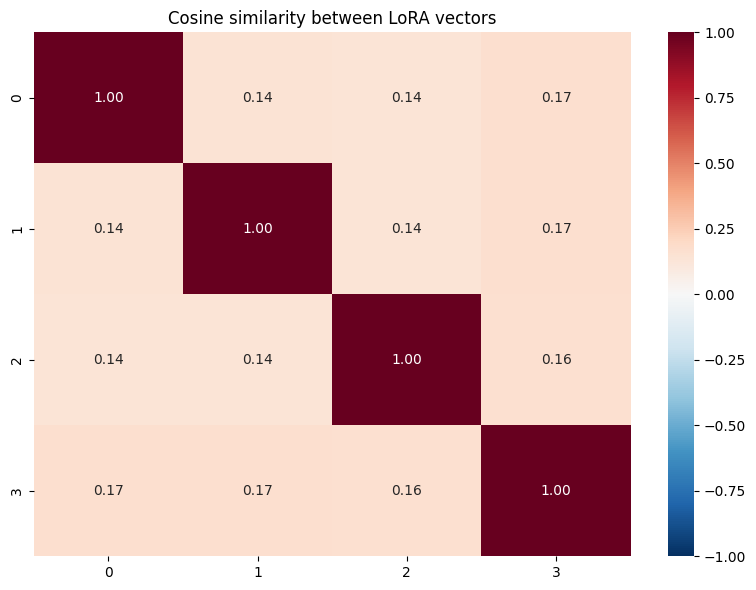

In [10]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns

import torch.nn.functional as F
from tqdm.auto import tqdm

paths = [
    hf_hub_download(
        "persona-shattering-lasr/20Feb-n-plus",
        filename="rerun-seed123/adapter_model.safetensors"
    ),
    hf_hub_download(
        "persona-shattering-lasr/20Feb-n-plus",
        filename="rerun-seed456/adapter_model.safetensors"
    ),
    hf_hub_download(
        "persona-shattering-lasr/20Feb-n-plus",
        filename="rerun-seed789/adapter_model.safetensors"
    ),
    hf_hub_download(
        "persona-shattering-lasr/20Feb-n-plus",
        filename="checkpoints/final/adapter_model.safetensors"
    )
]

N = len(paths)
cos_sim = torch.zeros(N, N)


# def cosine_sim_f32(a, b):
#     a, b = a.float(), b.float()
#     return (a @ b) / (a.norm() * b.norm())

def cosine_sim_safe(a, b, chunk_size=10_000_000):
    a, b = a.float(), b.float()
    dot = torch.tensor(0.0, dtype=torch.float64)
    norm_a = torch.tensor(0.0, dtype=torch.float64)
    norm_b = torch.tensor(0.0, dtype=torch.float64)
    for i in range(0, len(a), chunk_size):
        ac = a[i:i+chunk_size].double()
        bc = b[i:i+chunk_size].double()
        dot += (ac * bc).sum()
        norm_a += (ac * ac).sum()
        norm_b += (bc * bc).sum()
    return (dot / (norm_a.sqrt() * norm_b.sqrt()))


for i in tqdm(range(N)):
    flattened_lora_i = flatten_lora(load_file(paths[i]))
    for j in tqdm(range(i, N)):
        flattened_lora_j = flatten_lora(load_file(paths[j]))
        # sim = F.cosine_similarity(flattened_lora_i.unsqueeze(0), flattened_lora_j.unsqueeze(0)).item()
        sim = cosine_sim_safe(flattened_lora_i, flattened_lora_j).item()
        print(f"{i=}, {j=}, Cosine Sim {sim}")
        cos_sim[i, j] = sim
        cos_sim[j, i] = sim
        del flattened_lora_j
    del flattened_lora_i


fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cos_sim, ax=ax, vmin=-1, vmax=1, cmap="RdBu_r", annot=True, fmt=".2f")
ax.set_title("Cosine similarity between LoRA vectors")
plt.tight_layout()
plt.show()

# flatten_lora(load_file(paths[0])).shape